# Poisoning Experiment — Accuracy vs Poison Rate (Strategy A)
Sweep `poison_rate` x 3 prompt types x 5 models, k=5 fixed. Strategy A uses label-flipped passages (`opposite_label`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run (N=10)

# Poisoning strategy: "opposite_label" (Strategy A) or "llm_negation" (Strategy B).
# Strategy B uses the same LLM as the model-under-test to generate direct
# contradictions of each gold passage; results are cached so re-runs are free.
STRATEGY        = cfg["poisoning"].get("strategy", "opposite_label")

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 10 if DRY_RUN else cfg["evaluation"]["n_examples"]

total_calls = len(POISON_RATES) * len(PROMPT_TYPES) * len(MODELS) * N_EXAMPLES
print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}  strategy={STRATEGY}")
print(f"Grid: {len(POISON_RATES)} rates × {len(PROMPT_TYPES)} prompts × {len(MODELS)} models")
print(f"Estimated API calls: {total_calls}")

DRY_RUN=False  n_examples=50  strategy=opposite_label
Grid: 5 rates × 3 prompts × 5 models
Estimated API calls: 3750


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 15,935  |  Using: 50


In [3]:
def build_llm(model: str):
    return HuggingFaceClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

In [ ]:
def run_poisoning_sweep(examples, poison_rates, prompt_types, k, embedder, llm,
                        distractor_pool, seed, strategy="opposite_label"):
    """Sweep poison_rates x prompt_types for one open LLM. Returns list of row dicts."""
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_dataset(
                examples, poison_rate=poison_rate, seed=seed,
                strategy=strategy, llm=llm,
            )
            if poison_rate > 0.0
            else examples
        )
        for prompt_type in prompt_types:
            retriever = Retriever(embedder=embedder, k=k)
            metrics = run_scorer(
                examples=poisoned,
                retriever=retriever,
                llm=llm,
                prompt_type=prompt_type,
                distractor_pool_size=distractor_pool,
                seed=seed,
                self_consistency_runs=1,
            )
            rows.append({"model": model_name, "poison_rate": poison_rate,
                         "prompt_type": prompt_type, "strategy": strategy, **metrics})
            print(
                f"  {model_name.split('-')[0]:6s}  rate={poison_rate:.2f}  "
                f"prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
            )
    return rows

In [5]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)
all_rows = []

print(f"Starting full grid sweep (strategy={STRATEGY})...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        all_rows.extend(
            run_poisoning_sweep(
                examples=examples,
                poison_rates=POISON_RATES,
                prompt_types=PROMPT_TYPES,
                k=K,
                embedder=embedder,
                llm=llm,
                distractor_pool=DISTRACTOR_POOL,
                seed=SEED,
                strategy=STRATEGY,
            )
        )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions collected.")
results

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Starting full grid sweep (strategy=opposite_label)...

--- Model: Qwen/Qwen2.5-1.5B-Instruct ---
  Qwen/Qwen2.5  rate=0.00  prompt=standard         acc=0.500
  Qwen/Qwen2.5  rate=0.00  prompt=chain_of_thought  acc=0.580
  Qwen/Qwen2.5  rate=0.00  prompt=vigilant         acc=0.360
  Qwen/Qwen2.5  rate=0.25  prompt=standard         acc=0.420
  Qwen/Qwen2.5  rate=0.25  prompt=chain_of_thought  acc=0.540
  Qwen/Qwen2.5  rate=0.25  prompt=vigilant         acc=0.340
  Qwen/Qwen2.5  rate=0.50  prompt=standard         acc=0.500
  Qwen/Qwen2.5  rate=0.50  prompt=chain_of_thought  acc=0.500
  Qwen/Qwen2.5  rate=0.50  prompt=vigilant         acc=0.320
  Qwen/Qwen2.5  rate=0.75  prompt=standard         acc=0.440
  Qwen/Qwen2.5  rate=0.75  prompt=chain_of_thought  acc=0.500
  Qwen/Qwen2.5  rate=0.75  prompt=vigilant         acc=0.360
  Qwen/Qwen2.5  rate=1.00  prompt=standard         acc=0.420
  Qwen/Qwen2.5  rate=1.00  prompt=chain_of_thought  acc=0.500
  Qwen/Qwen2.5  rate=1.00  prompt=vigilant  

,model,poison_rate,prompt_type,strategy,accuracy,macro_f1,hallucination_rate,precision_at_k,contradiction_detection_rate
0,Qwen/Qwen2.5-1.5B-Instruct,0.00,standard,opposite_label,0.50,0.485727,0.235294,0.208,NaN
1,Qwen/Qwen2.5-1.5B-Instruct,0.00,chain_of_thought,opposite_label,0.58,0.493367,0.117647,0.208,NaN
2,Qwen/Qwen2.5-1.5B-Instruct,0.00,vigilant,opposite_label,0.36,0.213384,0.000000,0.208,0.0
3,Qwen/Qwen2.5-1.5B-Instruct,0.25,standard,opposite_label,0.42,0.378817,0.235294,0.156,NaN
4,Qwen/Qwen2.5-1.5B-Instruct,0.25,chain_of_thought,opposite_label,0.54,0.438503,0.117647,0.156,NaN
...,...,...,...,...,...,...,...,...,...
70,meta-llama/Llama-3.2-3B-Instruct,0.75,chain_of_thought,opposite_label,0.48,0.457778,0.294118,0.064,NaN
71,meta-llama/Llama-3.2-3B-Instruct,0.75,vigilant,opposite_label,0.38,0.308943,0.411765,0.064,0.0
72,meta-llama/Llama-3.2-3B-Instruct,1.00,standard,opposite_label,0.46,0.372387,0.000000,0.000,NaN
73,meta-llama/Llama-3.2-3B-Instruct,1.00,chain_of_thought,opposite_label,0.46,0.421958,0.176471,0.000,NaN


Saved → figures/03_accuracy_vs_poison_rate.png


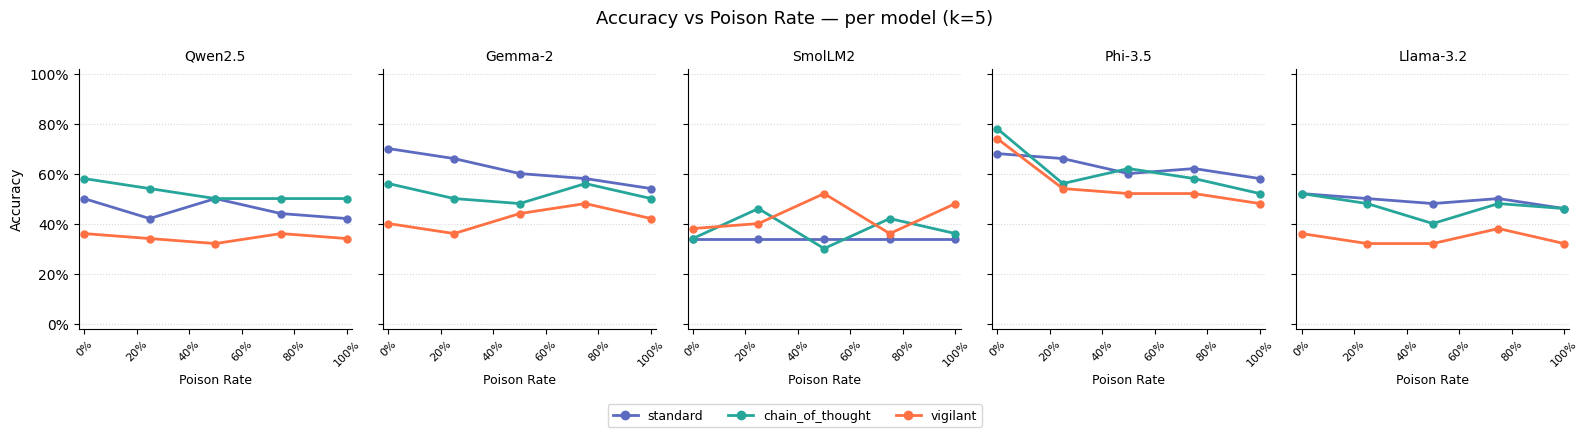

In [6]:
from nb_style import MODEL_LABELS, MODEL_COLORS, MODEL_MARKERS, MODEL_LS, PROMPT_COLORS

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["accuracy"],
            marker="o", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt], label=prompt,
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker="o", linewidth=2, label=p)
    for p in PROMPT_TYPES
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(f"Accuracy vs Poison Rate — per model (k={K})", fontsize=13)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_accuracy_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_accuracy_vs_poison_rate.png")
plt.show()

Saved → figures/03_hallucination_vs_poison_rate.png


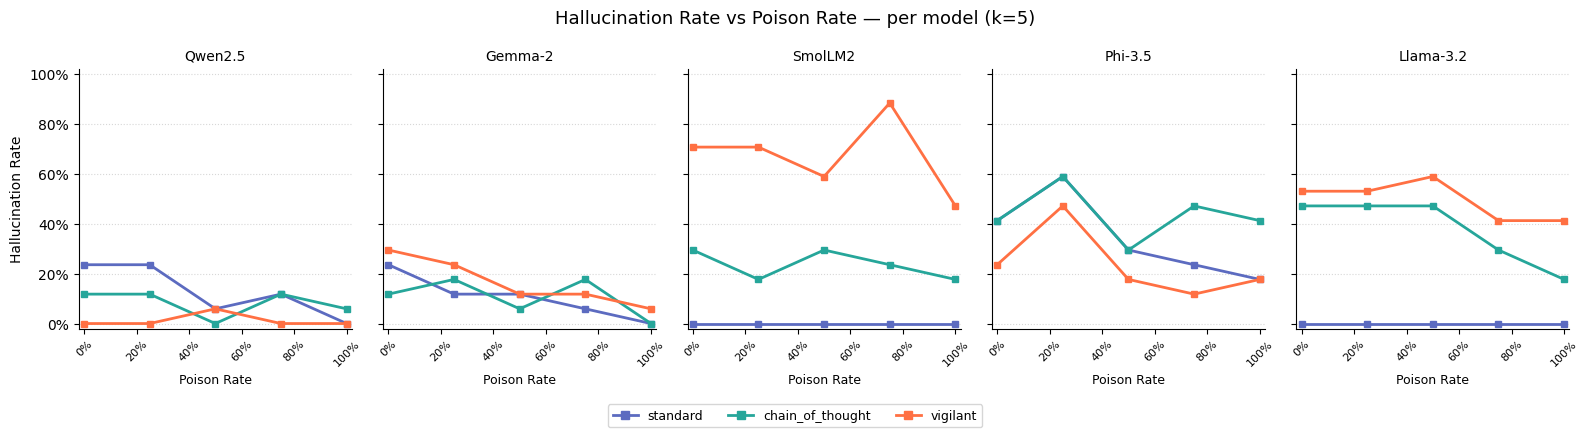

In [7]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["hallucination_rate"],
            marker="s", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt], label=prompt,
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Hallucination Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker="s", linewidth=2, label=p)
    for p in PROMPT_TYPES
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(f"Hallucination Rate vs Poison Rate — per model (k={K})", fontsize=13)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_hallucination_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_hallucination_vs_poison_rate.png")
plt.show()

In [ ]:
pivot = results.pivot_table(
    index=["model", "prompt_type"],
    columns="poison_rate",
    values="accuracy",
)
pivot.columns = [f"{c:.0%}" for c in pivot.columns]
pivot.index = pivot.index.map(lambda x: (MODEL_LABELS[x[0]], x[1]))
print("=== Accuracy pivot (rows: model x prompt, cols: poison_rate) ===")
print(pivot.to_string(float_format="{:.3f}".format))

---
## Qualitative Failure Analysis
No new LLM calls — all completions are served from disk cache.

In [9]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import prepare_cases, resolve
from src.evaluation.failures import (
    classify_failure,
    find_failure_examples,
    find_vigilant_contrast_examples,
)

# Use a single model + a small subset for qualitative analysis
QUAL_MODEL   = MODELS[0]   # first model in the config
QUAL_N       = min(50, N_EXAMPLES)  # enough examples to find interesting cases

all_examples = load_fever('../' + cfg['dataset']['fever_dev'])
qual_examples = all_examples[:QUAL_N]

emb = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)
llm = HuggingFaceClient(model=QUAL_MODEL, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

# Prepare per-prompt cases at two poison rates
with llm:
    # ---- 50% poison rate — standard ----
    poisoned_50 = poison_dataset(qual_examples, poison_rate=0.5, seed=SEED)
    ret_std  = Retriever(embedder=emb, k=K)
    ret_vig  = Retriever(embedder=emb, k=K)
    ret_high = Retriever(embedder=emb, k=K)
    cases_std  = prepare_cases(poisoned_50, ret_std,  prompt_type='standard',
                               distractor_pool_size=DISTRACTOR_POOL, seed=SEED)
    cases_vig  = prepare_cases(poisoned_50, ret_vig,  prompt_type='vigilant',
                               distractor_pool_size=DISTRACTOR_POOL, seed=SEED)
    results_std  = resolve(cases_std, llm)
    results_vig  = resolve(cases_vig, llm)
    # ---- 100% poison rate — standard (NEI collapse) ----
    poisoned_100 = poison_dataset(qual_examples, poison_rate=1.0, seed=SEED)
    ret_full = Retriever(embedder=emb, k=K)
    cases_full   = prepare_cases(poisoned_100, ret_full, prompt_type='standard',
                                 distractor_pool_size=DISTRACTOR_POOL, seed=SEED)
    results_full = resolve(cases_full, llm)

emb.close()
print(f'Loaded {len(cases_std)} cases for qualitative analysis (model={QUAL_MODEL.split("/")[-1]})')

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loaded 50 cases for qualitative analysis (model=Qwen2.5-1.5B-Instruct)


In [10]:
def display_example(case, result, annotation, title=None):
    """Pretty-print a single failure example."""
    if title:
        print(f'\n{'='*70}')
        print(f'  {title}')
        print(f'{'='*70}')
    gold_set = set(case.gold_passages)
    print(f'CLAIM    : {case.claim}')
    print(f'GOLD     : {case.gold_label}')
    print(f'PREDICTED: {result.predicted_label}')
    print()
    print('RETRIEVED PASSAGES:')
    for i, p in enumerate(case.passages, 1):
        tag = '[GOLD]    ' if p in gold_set else '[NON-GOLD]'
        snippet = p[:120].replace('\n', ' ')
        print(f'  {i}. {tag} {snippet}...' if len(p) > 120 else f'  {i}. {tag} {snippet}')
    print()
    print(f'ANNOTATION: {annotation}')
    print()

### Category 1 — Convinced by Minority Poison
Model predicts incorrectly despite most retrieved passages being gold evidence; a single adversarial passage dominates.

In [11]:
minority_examples = find_failure_examples(
    cases_std, results_std, 'convinced_by_minority_poison', max_examples=2
)

if minority_examples:
    for i, (case, result) in enumerate(minority_examples, 1):
        gold_set = set(case.gold_passages)
        n_non_gold = sum(1 for p in case.passages if p not in gold_set)
        annotation = (
            f'{n_non_gold}/{len(case.passages)} retrieved passages were non-gold, '
            f'yet the model predicted {result.predicted_label!r} instead of '
            f'{case.gold_label!r}. The minority non-gold passage(s) dominated '
            f'the model\'s reasoning over {len(case.passages) - n_non_gold} gold passages.'
        )
        display_example(case, result, annotation, title=f'Example C1.{i}')
else:
    print('No convinced-by-minority examples found in this subset — try increasing QUAL_N.')

No convinced-by-minority examples found in this subset — try increasing QUAL_N.


### Category 2 — Vigilant Prompt: Helps vs. Does Not Help
Same claim and passages, standard vs. vigilant prompting.

In [12]:
helped_examples = find_vigilant_contrast_examples(
    cases_std, results_std, results_vig, kind='helped', max_examples=1
)
failed_examples = find_vigilant_contrast_examples(
    cases_std, results_std, results_vig, kind='failed', max_examples=1
)

for label, examples in [('VIGILANT HELPS', helped_examples),
                         ('VIGILANT DOES NOT HELP', failed_examples)]:
    if examples:
        case, sr, vr = examples[0]
        gold_set = set(case.gold_passages)
        n_non_gold = sum(1 for p in case.passages if p not in gold_set)
        annotation = (
            f'[{label}] '
            f'Standard predicted {sr.predicted_label!r}, '
            f'Vigilant predicted {vr.predicted_label!r} '
            f'(gold: {case.gold_label!r}). '
            f'{n_non_gold}/{len(case.passages)} retrieved passages are non-gold.'
        )
        display_example(case, sr, annotation, title=label)
    else:
        print(f'{label}: no examples found in this subset.')


  VIGILANT HELPS
CLAIM    : The Greek language is spoken in films.
GOLD     : NOT ENOUGH INFO
PREDICTED: SUPPORTS

RETRIEVED PASSAGES:
  1. [GOLD]     The language is spoken by at least 13.2 million people today in Greece , Cyprus , Italy , Albania , Turkey , and the Gre...
  2. [NON-GOLD] The film centers on Stanley Jobson , an ex-con and computer hacker who is targeted for recruitment into a bank robbery c...
  3. [NON-GOLD] Roswell is an American science fiction television series developed , produced , and co-written by Jason Katims .
  4. [NON-GOLD] A View to a Kill -LRB- 1985 -RRB- is the fourteenth spy film of the James Bond series , and the seventh and last to star...
  5. [NON-GOLD] Caplan also starred in television shows The Class , True Blood , and Party Down .

ANNOTATION: [VIGILANT HELPS] Standard predicted 'SUPPORTS', Vigilant predicted 'NOT ENOUGH INFO' (gold: 'NOT ENOUGH INFO'). 4/5 retrieved passages are non-gold.


  VIGILANT DOES NOT HELP
CLAIM    : Jackie (2016 film

### Category 3 — NEI Collapse Under High Poison Rate
At `poison_rate=1.0` no gold passages are retrieved; model defaults to NOT ENOUGH INFO.

In [13]:
nei_examples = find_failure_examples(
    cases_full, results_full, 'nei_collapse', max_examples=2
)

if nei_examples:
    for i, (case, result) in enumerate(nei_examples, 1):
        annotation = (
            f'At 100% poison rate all {len(case.passages)} retrieved passages are '
            f'non-gold. The model collapses to {result.predicted_label!r} despite '
            f'the claim being definitively {case.gold_label!r}.'
        )
        display_example(case, result, annotation, title=f'Example C3.{i}')
else:
    print('No NEI-collapse examples found — try increasing QUAL_N.')


  Example C3.1
CLAIM    : Jackie (2016 film) was directed by Peter Jackson.
GOLD     : REFUTES
PREDICTED: NOT ENOUGH INFO

RETRIEVED PASSAGES:
  1. [NON-GOLD] It is a remake of the 1972 Fist of Fury , which starred Bruce Lee as the lead character .
  2. [NON-GOLD] A View to a Kill -LRB- 1985 -RRB- is the fourteenth spy film of the James Bond series , and the seventh and last to star...
  3. [NON-GOLD] In 2017 , she portrayed Belle in a live-action adaptation of Beauty and the Beast .
  4. [NON-GOLD] The film centers on Stanley Jobson , an ex-con and computer hacker who is targeted for recruitment into a bank robbery c...
  5. [NON-GOLD] The film centers on Stanley Jobson , an ex-con and computer hacker who is targeted for recruitment into a bank robbery c...

ANNOTATION: At 100% poison rate all 5 retrieved passages are non-gold. The model collapses to 'NOT ENOUGH INFO' despite the claim being definitively 'REFUTES'.


  Example C3.2
CLAIM    : The CONCACAF Champions League is organize

## Findings

Phi-3.5 and Gemma-2 reach the highest clean accuracy (Phi-3.5 CoT: 0.78, Gemma-2 standard: 0.70). SmolLM2 standard flatlines at 0.34 across all poison rates, suggesting it ignores retrieved context entirely. Overall degradation from 0% to 100% poison is modest (5-20 pp), consistent with Strategy A (`opposite_label`) producing weak adversarial signal. The vigilant prompt reduces hallucination but also reduces clean accuracy on several models, offering no reliable robustness advantage under Strategy A.

| Category | Observation |
|---|---|
| Convinced by minority poison | Not found in subset — Strategy A distractors may be too weak to override gold evidence |
| Vigilant prompt | Helped on 1 example (NEI correctly recovered); failed when non-gold passages dominated |
| NEI collapse | At 100% poison, REFUTES claims are consistently misclassified as NOT ENOUGH INFO |